In [1]:
import os
import torch
import numpy as np
import random

def seed_everything(seed):
    """
    Set random seed for reproducibility
    """
    # 1. Python & Numpy
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    
    # 2. PyTorch (CPU & GPU)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    print(f"🔒 Locked Random Seed: {seed}")


In [2]:



def seed_everything_random():
    """
    Tạo random seed, set seed đó, và return seed để bạn biết
    """
    # Tạo random seed
    random_seed = random.randint(0, 999999)
    
    # Set seed
    torch.manual_seed(random_seed)
    torch.cuda.manual_seed(random_seed)
    torch.cuda.manual_seed_all(random_seed)
    np.random.seed(random_seed)
    random.seed(random_seed)
    
    # Để reproducible
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    return random_seed


In [3]:
#import
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [4]:
#load data
df_men =pd.read_csv(r"/home/ducm/RERUM/dataset/Hillstrom-Men.csv")
df_men = df_men.drop(columns="Unnamed: 0")
print ("---------------------------")
print ("null count:")
print (df_men.isnull().sum())
print ("---------------------------")
print(df_men.dtypes)
print ("---------------------------")
print ("labels:")
print(df_men.columns.tolist())
print ("---------------------------")
print("data shape:")
print(df_men.shape)

---------------------------
null count:
recency            0
history_segment    0
history            0
mens               0
womens             0
zip_code           0
newbie             0
channel            0
visit              0
conversion         0
spend              0
treatment          0
dtype: int64
---------------------------
recency              int64
history_segment      int64
history            float64
mens                 int64
womens               int64
zip_code            object
newbie               int64
channel             object
visit                int64
conversion           int64
spend              float64
treatment            int64
dtype: object
---------------------------
labels:
['recency', 'history_segment', 'history', 'mens', 'womens', 'zip_code', 'newbie', 'channel', 'visit', 'conversion', 'spend', 'treatment']
---------------------------
data shape:
(42613, 12)


In [5]:
#Hillstrom-men
#split num and cate
cate_cols = ['zip_code', 'channel']
num_cols = ['recency', 'history_segment', 'history']
#split x y t
y_men = df_men["spend"]
t_men = df_men["treatment"]
x_men = df_men.drop(columns=["spend", "treatment", "visit", "conversion"])

# x_men_encode = pd.get_dummies(x_men, columns=cate_cols, drop_first=True)
# x_men_encode = x_men_encode.astype(float)

#train test split - stratify CHỈ bằng treatment
x_men_train, x_men_test, t_men_train, t_men_test, y_men_train, y_men_test = train_test_split(
    x_men, t_men.values, y_men.values,
    test_size=0.3, random_state=42, stratify= t_men
)

# Tạo stratify cho val split - chỉ dùng treatment
stratify_var_train = pd.Series(t_men_train)

x_men_train, x_men_val, t_men_train, t_men_val, y_men_train, y_men_val = train_test_split(
    x_men_train, t_men_train, y_men_train,
    test_size=(1/7), random_state=42, stratify= t_men_train
)

# Fit get_dummies trên train, sau đó align với val/test
x_men_train_encode = pd.get_dummies(x_men_train, columns=cate_cols, drop_first=True)
x_men_val_encode = pd.get_dummies(x_men_val, columns=cate_cols, drop_first=True)
x_men_test_encode = pd.get_dummies(x_men_test, columns=cate_cols, drop_first=True)

# Align columns
x_men_val_encode = x_men_val_encode.reindex(columns=x_men_train_encode.columns, fill_value=0)
x_men_test_encode = x_men_test_encode.reindex(columns=x_men_train_encode.columns, fill_value=0)

scaler = StandardScaler()
x_men_train= scaler.fit_transform(x_men_train_encode)
x_men_val = scaler.transform(x_men_val_encode)
x_men_test = scaler.transform(x_men_test_encode)

print ("✅ Train/Val/Test split with stratification ONLY by treatment (NO DATA LEAKAGE)")
print (f"Train: {x_men_train.shape}, Val: {x_men_val.shape}, Test: {x_men_test.shape}")
print (f"Treatment distribution - Train: {np.mean(t_men_train):.2%}, Val: {np.mean(t_men_val):.2%}, Test: {np.mean(t_men_test):.2%}")
print (f"Spend mean - Train: {np.mean(y_men_train):.2f}, Val: {np.mean(y_men_val):.2f}, Test: {np.mean(y_men_test):.2f}")

# x_men = pd.DataFrame(x_men_train)
x_men_train

✅ Train/Val/Test split with stratification ONLY by treatment (NO DATA LEAKAGE)
Train: (25567, 10), Val: (4262, 10), Test: (12784, 10)
Treatment distribution - Train: 50.00%, Val: 50.00%, Test: 50.00%
Spend mean - Train: 1.00, Val: 0.95, Test: 1.14


array([[-1.36323828, -0.95770591, -0.65534372, ...,  1.22273126,
        -0.87900784,  1.12185957],
       [ 0.63260109, -0.30863193, -0.31367375, ...,  1.22273126,
        -0.87900784,  1.12185957],
       [ 0.34748118, -0.30863193, -0.4344948 , ...,  1.22273126,
         1.13764628, -0.89137716],
       ...,
       [ 0.34748118,  0.34044206,  0.30319097, ..., -0.8178412 ,
        -0.87900784,  1.12185957],
       [-1.07811837,  0.34044206,  0.16319135, ..., -0.8178412 ,
         1.13764628, -0.89137716],
       [-0.79299846, -0.95770591, -0.61911315, ..., -0.8178412 ,
        -0.87900784,  1.12185957]], shape=(25567, 10))

In [6]:
#Transform to tensor
def to_tensor(df):
    return torch.tensor(df, dtype=torch.float32)
batch_size = 800
x_men_train_t = to_tensor(x_men_train)
x_men_val_t = to_tensor(x_men_val)
x_men_test_t = to_tensor(x_men_test)

y_men_train_t = to_tensor(y_men_train).unsqueeze(1)
y_men_val_t = to_tensor(y_men_val).unsqueeze(1)
y_men_test_t = to_tensor(y_men_test).unsqueeze(1)

t_men_train_t = to_tensor(t_men_train.astype(float)).unsqueeze(1)
t_men_val_t = to_tensor(t_men_val.astype(float)).unsqueeze(1)
t_men_test_t = to_tensor(t_men_test.astype(float)).unsqueeze(1)

# sampler = get_sampler(y_men_train_t, target_positive_ratio=0.2)

#Data loader
train_dataset = TensorDataset(x_men_train_t, t_men_train_t, y_men_train_t)
val_dataset = TensorDataset(x_men_val_t, t_men_val_t, y_men_val_t)
test_dataset = TensorDataset(x_men_test_t, t_men_test_t, y_men_test_t)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print ("-------------------------------------------------------------")
print ("✅Completed tranform to tensor✅")
print (f"Shape of train: x={x_men_train_t.shape}; y ={y_men_train_t.shape}; t={t_men_train_t.shape}")
print (f"Shape of val: x={x_men_val_t.shape}; y={y_men_val_t.shape}; t={t_men_val_t.shape}")
print (f"Shape of test: x={x_men_test_t.shape}; y={y_men_test_t.shape}; t={t_men_test_t.shape}")

-------------------------------------------------------------
✅Completed tranform to tensor✅
Shape of train: x=torch.Size([25567, 10]); y =torch.Size([25567, 1]); t=torch.Size([25567, 1])
Shape of val: x=torch.Size([4262, 10]); y=torch.Size([4262, 1]); t=torch.Size([4262, 1])
Shape of test: x=torch.Size([12784, 10]); y=torch.Size([12784, 1]); t=torch.Size([12784, 1])


Evaluation metrics

In [7]:
from metrics import auuc, auqc, lift, krcc

Build Model

In [8]:
from tarnet import Tarnet

In [9]:
print("📊 Data Distribution Check:")
print(f"Y train: mean={y_men_train.mean():.4f}, std={y_men_train.std():.4f}")
print(f"Y train zeros: {(y_men_train == 0).sum()} / {len(y_men_train)} ({(y_men_train == 0).sum()/len(y_men_train)*100:.1f}%)")
print(f"\nTreatment balance:")
print(f"  Train: {(t_men_train == 1).sum()} treated, {(t_men_train == 0).sum()} control")
print(f"  Test:  {(t_men_test == 1).sum()} treated, {(t_men_test == 0).sum()} control")

📊 Data Distribution Check:
Y train: mean=1.0015, std=14.5993
Y train zeros: 25338 / 25567 (99.1%)

Treatment balance:
  Train: 12784 treated, 12783 control
  Test:  6392 treated, 6392 control


In [10]:
epochs = 25
lr = 1e-4
wd = 1e-4
early_stop_metric = "loss"
ema = True
ema_alpha = 0.15
patience = 15
shared_dropout = 0
outcome_droupout = 0 
shared_hidden = 200
outcome_hidden = 100
early_stop_start =  0
print (f" early stop start = {early_stop_start}")
print (f" epochs = {epochs}")
print (f" learning rate = {lr}")
print (f" weight decay = {wd}")
print (f" early stop = {early_stop_metric}")
print (f" use ema = {ema}")
print (f" ema alpha = {ema_alpha}")
print (f" patience = {patience}")
print (f" share dropout = {shared_dropout}")
print (f" outcome dropout = {outcome_droupout}")
print (f" shared hidden = {shared_hidden}")
print (f" outcome hidden = {outcome_hidden}")


 early stop start = 0
 epochs = 25
 learning rate = 0.0001
 weight decay = 0.0001
 early stop = loss
 use ema = True
 ema alpha = 0.15
 patience = 15
 share dropout = 0
 outcome dropout = 0
 shared hidden = 200
 outcome hidden = 100


🔒 Locked Random Seed: 412312
🔃🔃🔃Begin training Tarnet🔃🔃🔃
📊 Early Stop Metric: LOSS
📊 Early Stop Start Epoch: 1
📊 Strategy: Train for 25 epochs, select model with lowest validation loss
   Patience: 15 epochs
Epoch 1/25 | Loss: 1.9153 | Cls: 1.2640 | Reg: 0.6513 | Val Loss: 1.6773 | F1_c: 0.0556 | AUC_c: 0.5262 | F1_t: 0.0000 | AUC_t: 0.3781 | Val Qini: 0.1238 ⭐ NEW BEST (lowest loss)
Epoch 2/25 | Loss: 1.0451 | Cls: 0.8177 | Reg: 0.2273 | Val Loss: 1.0775 | F1_c: 0.1111 | AUC_c: 0.4954 | F1_t: 0.0000 | AUC_t: 0.3789 | Val Qini: -0.4130 ⭐ NEW BEST (lowest loss)
Epoch 3/25 | Loss: 0.3030 | Cls: 0.1559 | Reg: 0.1471 | Val Loss: 0.2627 | F1_c: 0.0556 | AUC_c: 0.5057 | F1_t: 0.0000 | AUC_t: 0.3823 | Val Qini: -0.0610 ⭐ NEW BEST (lowest loss)
Epoch 4/25 | Loss: 0.2395 | Cls: 0.1169 | Reg: 0.1226 | Val Loss: 0.2147 | F1_c: 0.1111 | AUC_c: 0.5269 | F1_t: 0.0000 | AUC_t: 0.3899 | Val Qini: -0.1340 ⭐ NEW BEST (lowest loss)
Epoch 5/25 | Loss: 0.2255 | Cls: 0.1080 | Reg: 0.1175 | Val Loss: 0.2111 

/home/ducm/RERUM/Tarnet + ziln/tarnet.py:370: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float32, device=self.device)


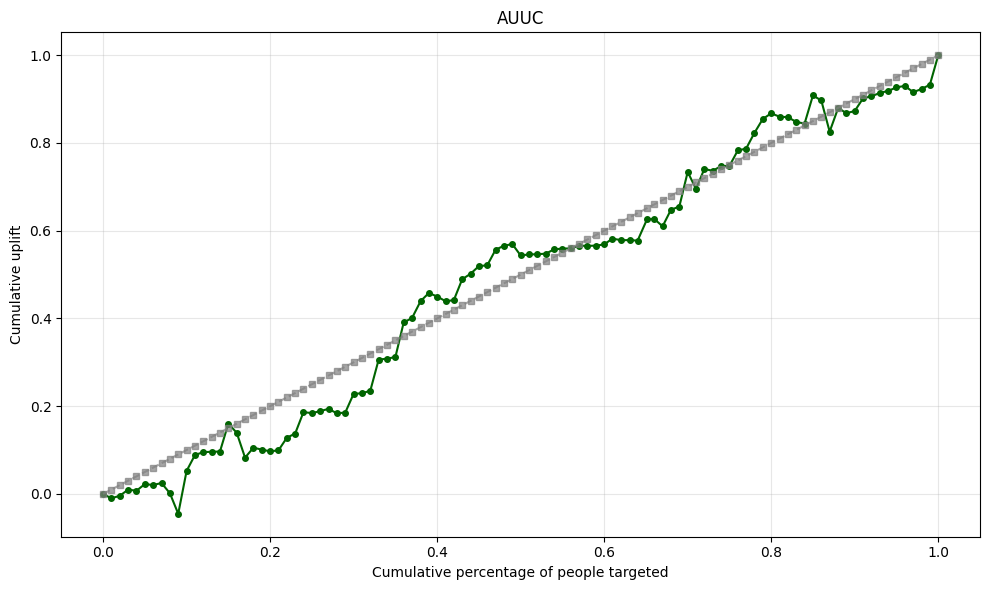

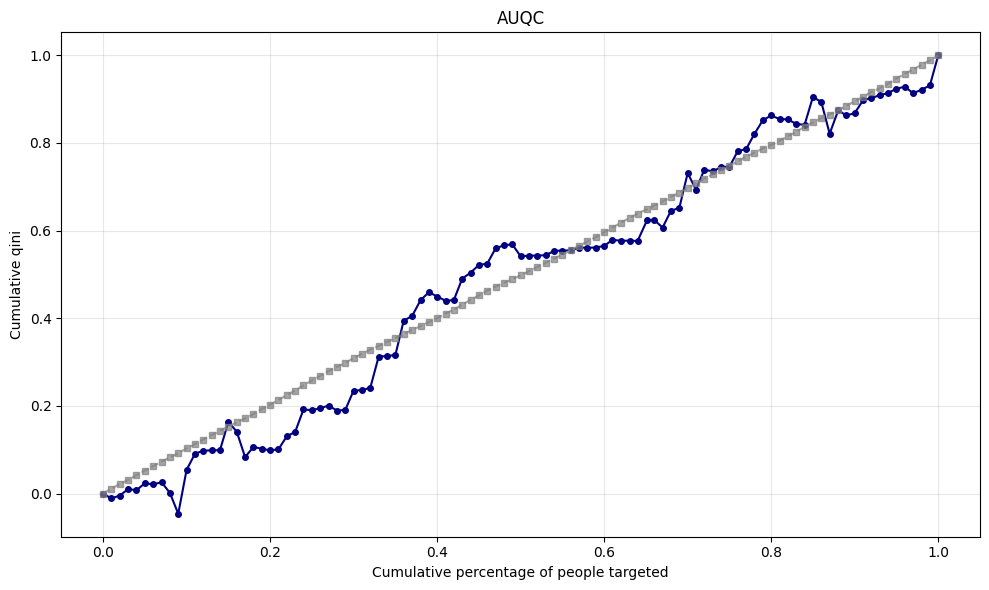

----------------------------------------
[ORIGINAL TEST SET]
AUUC: 0.485
AUQC: 0.485
Lift: 0.781
KRCC: -0.038
ATE (predicted): 0.5825
ATE (true): 1.0265
ATE error: 0.4440


In [11]:
seed = 412312
seed_everything(seed)

tarnet = Tarnet(input_dim=x_men_train_t.shape[1], epochs=epochs, 
                      learning_rate=lr, 
                      weight_decay=wd,
                      use_ema=ema,
                      ema_alpha=ema_alpha,
                      patience=patience,
                      shared_hidden=shared_hidden,
                      outcome_hidden=outcome_hidden,
                      outcome_dropout=outcome_droupout,
                      shared_dropout=shared_dropout,
                      early_stop_metric=early_stop_metric,
                      early_stop_start_epoch=early_stop_start,
)
tarnet.fit(train_loader, val_loader)

print ("Complete training")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Evaluate on ORIGINAL test set ===
print("=" * 50)
print("Evaluating on ORIGINAL test set 🔃🔃🔃")
x_men_test_t_on_device = x_men_test_t.to(device)
y0_pred, y1_pred = tarnet.predict(x_men_test_t_on_device)
uplift_pred = (y1_pred - y0_pred).cpu().numpy().flatten()
y_true = y_men_test_t.cpu().numpy().flatten()
t_true = t_men_test_t.cpu().numpy().flatten()

auuc_score = auuc(y_true, t_true, uplift_pred, bins=100, plot=True)
auqc_score = auqc(y_true, t_true, uplift_pred, bins=100, plot=True)
lift_score = lift(y_true, t_true, uplift_pred, h=0.3)
krcc_score = krcc(y_true, t_true, uplift_pred, bins=100)
ate_pred = uplift_pred.mean()
ate_true = y_true[t_true == 1].mean() - y_true[t_true == 0].mean()

print("-" * 40)
print("[ORIGINAL TEST SET]")
print(f"AUUC: {auuc_score:.3f}")
print(f"AUQC: {auqc_score:.3f}")
print(f"Lift: {lift_score:.3f}")
print(f"KRCC: {krcc_score:.3f}")
print(f"ATE (predicted): {ate_pred:.4f}")
print(f"ATE (true): {ate_true:.4f}")
print(f"ATE error: {abs(ate_pred - ate_true):.4f}")

🔒 Locked Random Seed: 42
🔃🔃🔃Begin training Tarnet🔃🔃🔃
📊 Early Stop Metric: LOSS
📊 Early Stop Start Epoch: 1
📊 Strategy: Train for 25 epochs, select model with lowest validation loss
   Patience: 15 epochs
Epoch 1/25 | Loss: 1.5026 | Cls: 1.2781 | Reg: 0.2245 | Val Loss: 1.6503 | F1_c: 0.0000 | AUC_c: 0.4996 | F1_t: 0.0000 | AUC_t: 0.5033 | Val Qini: -0.8542 ⭐ NEW BEST (lowest loss)
Epoch 2/25 | Loss: 1.2928 | Cls: 0.8467 | Reg: 0.4462 | Val Loss: 1.0779 | F1_c: 0.0000 | AUC_c: 0.4057 | F1_t: 0.0000 | AUC_t: 0.4517 | Val Qini: -1.0235 ⭐ NEW BEST (lowest loss)
Epoch 3/25 | Loss: 0.1449 | Cls: 0.0942 | Reg: 0.0507 | Val Loss: 0.2404 | F1_c: 0.0000 | AUC_c: 0.3719 | F1_t: 0.0000 | AUC_t: 0.4507 | Val Qini: -1.3712 ⭐ NEW BEST (lowest loss)
Epoch 4/25 | Loss: 0.2043 | Cls: 0.1055 | Reg: 0.0988 | Val Loss: 0.2116 | F1_c: 0.0000 | AUC_c: 0.3874 | F1_t: 0.0000 | AUC_t: 0.4722 | Val Qini: -1.8501 ⭐ NEW BEST (lowest loss)
Epoch 5/25 | Loss: 0.1991 | Cls: 0.0894 | Reg: 0.1098 | Val Loss: 0.2068 | F

/home/ducm/RERUM/Tarnet + ziln/tarnet.py:370: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float32, device=self.device)


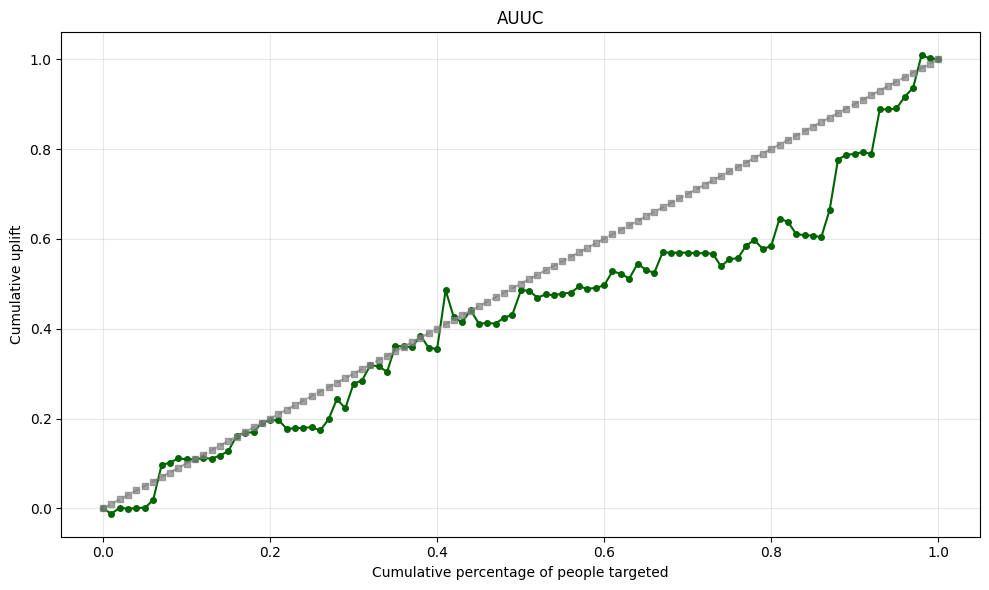

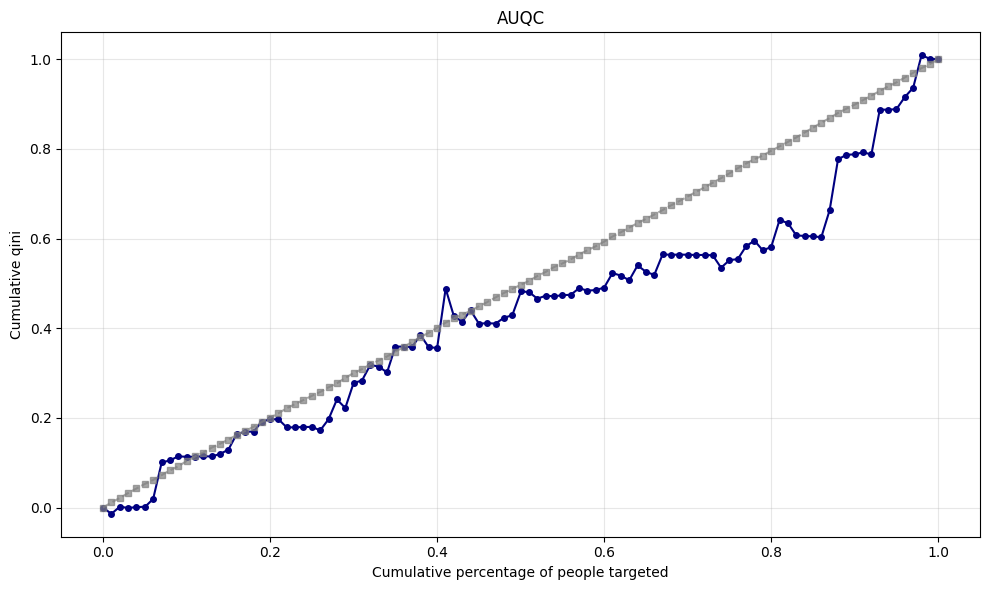

----------------------------------------
[ORIGINAL TEST SET]
AUUC: 0.430
AUQC: 0.428
Lift: 0.951
KRCC: -0.023
ATE (predicted): 0.9258
ATE (true): 1.0265
ATE error: 0.1007


In [12]:
seed = 42
seed_everything(seed)

tarnet = Tarnet(input_dim=x_men_train_t.shape[1], epochs=epochs, 
                      learning_rate=lr, 
                      weight_decay=wd,
                      use_ema=ema,
                      ema_alpha=ema_alpha,
                      patience=patience,
                      shared_hidden=shared_hidden,
                      outcome_hidden=outcome_hidden,
                      outcome_dropout=outcome_droupout,
                      shared_dropout=shared_dropout,
                      early_stop_metric=early_stop_metric,
                      early_stop_start_epoch=early_stop_start,
)
tarnet.fit(train_loader, val_loader)

print ("Complete training")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Evaluate on ORIGINAL test set ===
print("=" * 50)
print("Evaluating on ORIGINAL test set 🔃🔃🔃")
x_men_test_t_on_device = x_men_test_t.to(device)
y0_pred, y1_pred = tarnet.predict(x_men_test_t_on_device)
uplift_pred = (y1_pred - y0_pred).cpu().numpy().flatten()
y_true = y_men_test_t.cpu().numpy().flatten()
t_true = t_men_test_t.cpu().numpy().flatten()

auuc_score = auuc(y_true, t_true, uplift_pred, bins=100, plot=True)
auqc_score = auqc(y_true, t_true, uplift_pred, bins=100, plot=True)
lift_score = lift(y_true, t_true, uplift_pred, h=0.3)
krcc_score = krcc(y_true, t_true, uplift_pred, bins=100)
ate_pred = uplift_pred.mean()
ate_true = y_true[t_true == 1].mean() - y_true[t_true == 0].mean()

print("-" * 40)
print("[ORIGINAL TEST SET]")
print(f"AUUC: {auuc_score:.3f}")
print(f"AUQC: {auqc_score:.3f}")
print(f"Lift: {lift_score:.3f}")
print(f"KRCC: {krcc_score:.3f}")
print(f"ATE (predicted): {ate_pred:.4f}")
print(f"ATE (true): {ate_true:.4f}")
print(f"ATE error: {abs(ate_pred - ate_true):.4f}")

🔒 Locked Random Seed: 1874
🔃🔃🔃Begin training Tarnet🔃🔃🔃
📊 Early Stop Metric: LOSS
📊 Early Stop Start Epoch: 1
📊 Strategy: Train for 25 epochs, select model with lowest validation loss
   Patience: 15 epochs
Epoch 1/25 | Loss: 1.7196 | Cls: 1.2897 | Reg: 0.4299 | Val Loss: 1.6425 | F1_c: 0.0000 | AUC_c: 0.4801 | F1_t: 0.0000 | AUC_t: 0.6062 | Val Qini: -1.4457 ⭐ NEW BEST (lowest loss)
Epoch 2/25 | Loss: 0.9763 | Cls: 0.8137 | Reg: 0.1625 | Val Loss: 1.0708 | F1_c: 0.0000 | AUC_c: 0.5302 | F1_t: 0.0000 | AUC_t: 0.5747 | Val Qini: -2.2157 ⭐ NEW BEST (lowest loss)
Epoch 3/25 | Loss: 0.2717 | Cls: 0.1381 | Reg: 0.1336 | Val Loss: 0.2887 | F1_c: 0.0000 | AUC_c: 0.5616 | F1_t: 0.0000 | AUC_t: 0.5637 | Val Qini: -2.1214 ⭐ NEW BEST (lowest loss)
Epoch 4/25 | Loss: 0.3021 | Cls: 0.1375 | Reg: 0.1646 | Val Loss: 0.2178 | F1_c: 0.0000 | AUC_c: 0.5636 | F1_t: 0.0000 | AUC_t: 0.5575 | Val Qini: -2.1393 ⭐ NEW BEST (lowest loss)
Epoch 5/25 | Loss: 0.2054 | Cls: 0.0940 | Reg: 0.1114 | Val Loss: 0.2123 |

/home/ducm/RERUM/Tarnet + ziln/tarnet.py:370: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float32, device=self.device)


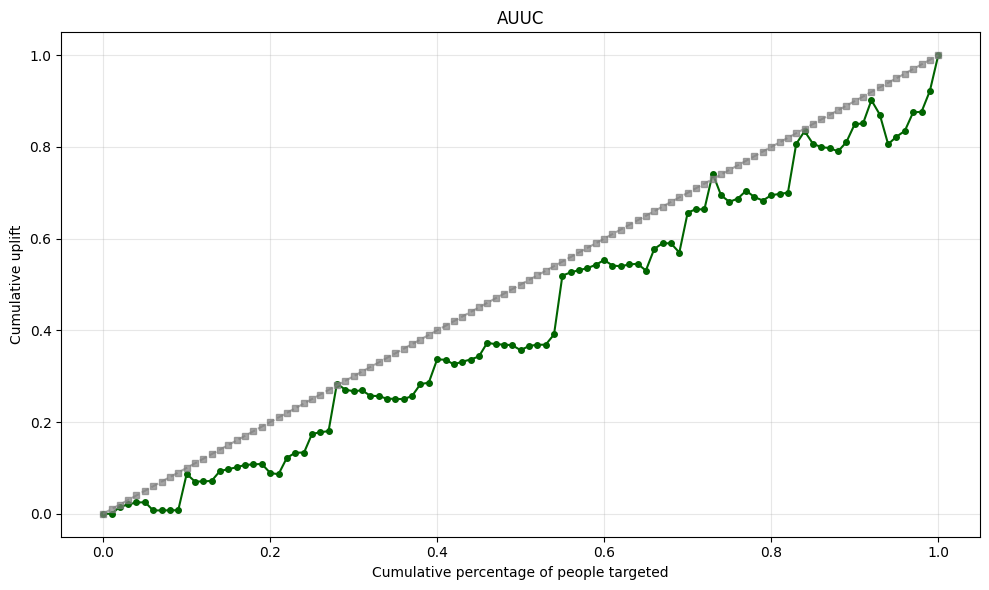

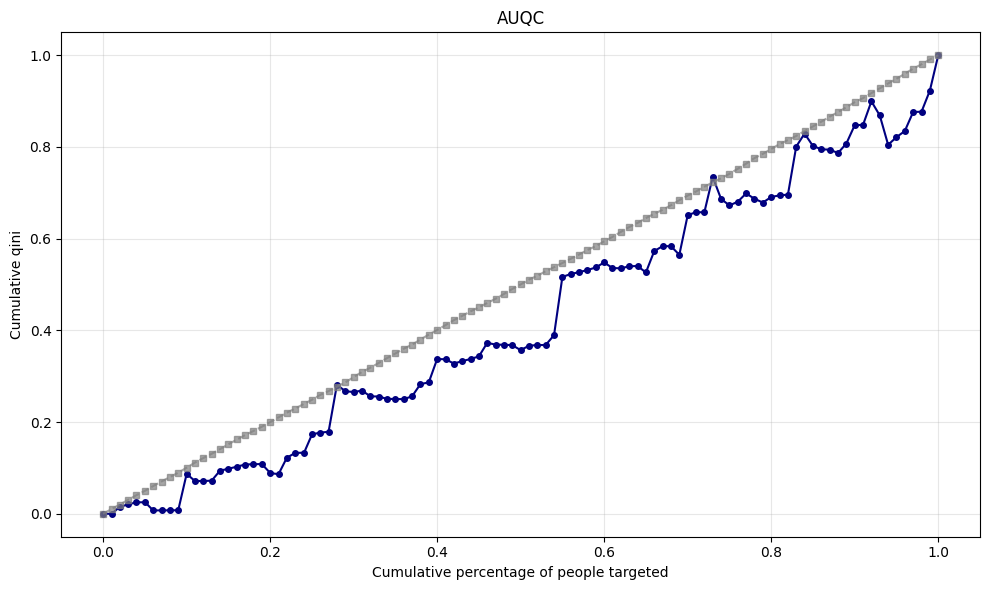

----------------------------------------
[ORIGINAL TEST SET]
AUUC: 0.426
AUQC: 0.424
Lift: 0.916
KRCC: -0.077
ATE (predicted): 0.7402
ATE (true): 1.0265
ATE error: 0.2863


In [13]:
seed = 1874
seed_everything(seed)

tarnet = Tarnet(input_dim=x_men_train_t.shape[1], epochs=epochs, 
                      learning_rate=lr, 
                      weight_decay=wd,
                      use_ema=ema,
                      ema_alpha=ema_alpha,
                      patience=patience,
                      shared_hidden=shared_hidden,
                      outcome_hidden=outcome_hidden,
                      outcome_dropout=outcome_droupout,
                      shared_dropout=shared_dropout,
                      early_stop_metric=early_stop_metric,
                      early_stop_start_epoch=early_stop_start,
)
tarnet.fit(train_loader, val_loader)

print ("Complete training")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Evaluate on ORIGINAL test set ===
print("=" * 50)
print("Evaluating on ORIGINAL test set 🔃🔃🔃")
x_men_test_t_on_device = x_men_test_t.to(device)
y0_pred, y1_pred = tarnet.predict(x_men_test_t_on_device)
uplift_pred = (y1_pred - y0_pred).cpu().numpy().flatten()
y_true = y_men_test_t.cpu().numpy().flatten()
t_true = t_men_test_t.cpu().numpy().flatten()

auuc_score = auuc(y_true, t_true, uplift_pred, bins=100, plot=True)
auqc_score = auqc(y_true, t_true, uplift_pred, bins=100, plot=True)
lift_score = lift(y_true, t_true, uplift_pred, h=0.3)
krcc_score = krcc(y_true, t_true, uplift_pred, bins=100)
ate_pred = uplift_pred.mean()
ate_true = y_true[t_true == 1].mean() - y_true[t_true == 0].mean()

print("-" * 40)
print("[ORIGINAL TEST SET]")
print(f"AUUC: {auuc_score:.3f}")
print(f"AUQC: {auqc_score:.3f}")
print(f"Lift: {lift_score:.3f}")
print(f"KRCC: {krcc_score:.3f}")
print(f"ATE (predicted): {ate_pred:.4f}")
print(f"ATE (true): {ate_true:.4f}")
print(f"ATE error: {abs(ate_pred - ate_true):.4f}")

🔒 Locked Random Seed: 902745
🔃🔃🔃Begin training Tarnet🔃🔃🔃
📊 Early Stop Metric: LOSS
📊 Early Stop Start Epoch: 1
📊 Strategy: Train for 25 epochs, select model with lowest validation loss
   Patience: 15 epochs
Epoch 1/25 | Loss: 1.5773 | Cls: 1.2907 | Reg: 0.2866 | Val Loss: 1.6700 | F1_c: 0.0000 | AUC_c: 0.4369 | F1_t: 0.0000 | AUC_t: 0.4102 | Val Qini: -1.7258 ⭐ NEW BEST (lowest loss)
Epoch 2/25 | Loss: 1.1832 | Cls: 0.8547 | Reg: 0.3285 | Val Loss: 1.0752 | F1_c: 0.0000 | AUC_c: 0.4381 | F1_t: 0.0000 | AUC_t: 0.4090 | Val Qini: -1.4912 ⭐ NEW BEST (lowest loss)
Epoch 3/25 | Loss: 0.2042 | Cls: 0.1107 | Reg: 0.0935 | Val Loss: 0.2483 | F1_c: 0.0000 | AUC_c: 0.4709 | F1_t: 0.0000 | AUC_t: 0.3933 | Val Qini: -1.3067 ⭐ NEW BEST (lowest loss)
Epoch 4/25 | Loss: 0.2614 | Cls: 0.1351 | Reg: 0.1263 | Val Loss: 0.2097 | F1_c: 0.0000 | AUC_c: 0.4991 | F1_t: 0.0000 | AUC_t: 0.4005 | Val Qini: -1.4109 ⭐ NEW BEST (lowest loss)
Epoch 5/25 | Loss: 0.3582 | Cls: 0.1541 | Reg: 0.2042 | Val Loss: 0.2065

/home/ducm/RERUM/Tarnet + ziln/tarnet.py:370: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float32, device=self.device)


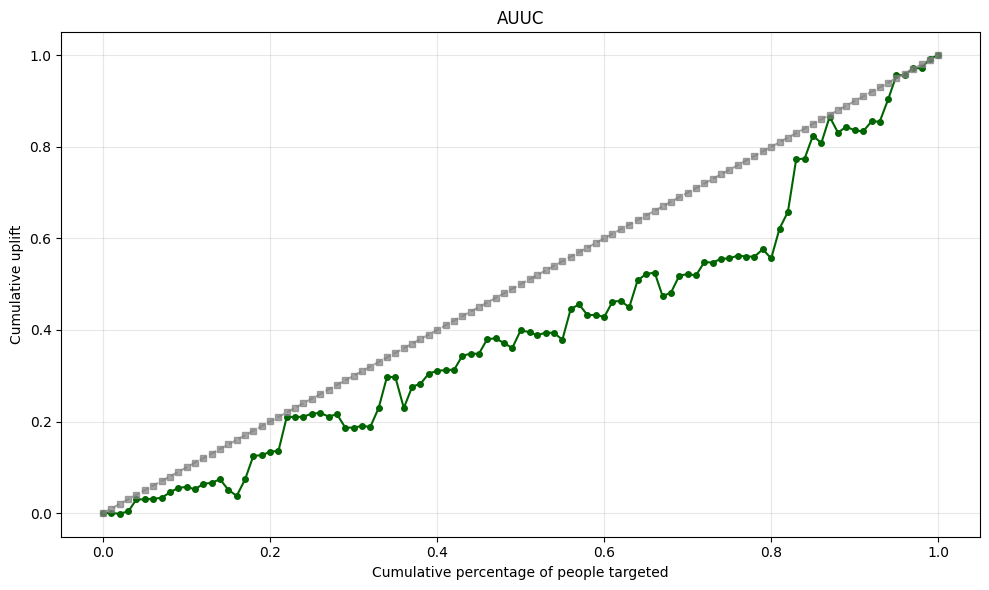

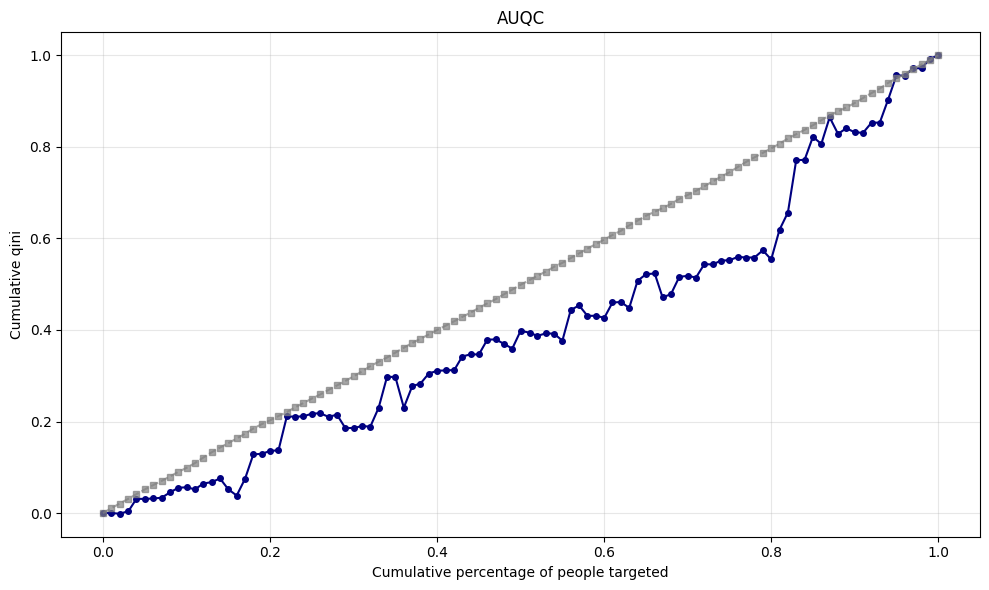

----------------------------------------
[ORIGINAL TEST SET]
AUUC: 0.405
AUQC: 0.404
Lift: 0.639
KRCC: -0.069
ATE (predicted): 0.8164
ATE (true): 1.0265
ATE error: 0.2100


In [14]:
seed = 902745
seed_everything(seed)

tarnet = Tarnet(input_dim=x_men_train_t.shape[1], epochs=epochs, 
                      learning_rate=lr, 
                      weight_decay=wd,
                      use_ema=ema,
                      ema_alpha=ema_alpha,
                      patience=patience,
                      shared_hidden=shared_hidden,
                      outcome_hidden=outcome_hidden,
                      outcome_dropout=outcome_droupout,
                      shared_dropout=shared_dropout,
                      early_stop_metric=early_stop_metric,
                      early_stop_start_epoch=early_stop_start,
)
tarnet.fit(train_loader, val_loader)

print ("Complete training")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Evaluate on ORIGINAL test set ===
print("=" * 50)
print("Evaluating on ORIGINAL test set 🔃🔃🔃")
x_men_test_t_on_device = x_men_test_t.to(device)
y0_pred, y1_pred = tarnet.predict(x_men_test_t_on_device)
uplift_pred = (y1_pred - y0_pred).cpu().numpy().flatten()
y_true = y_men_test_t.cpu().numpy().flatten()
t_true = t_men_test_t.cpu().numpy().flatten()

auuc_score = auuc(y_true, t_true, uplift_pred, bins=100, plot=True)
auqc_score = auqc(y_true, t_true, uplift_pred, bins=100, plot=True)
lift_score = lift(y_true, t_true, uplift_pred, h=0.3)
krcc_score = krcc(y_true, t_true, uplift_pred, bins=100)
ate_pred = uplift_pred.mean()
ate_true = y_true[t_true == 1].mean() - y_true[t_true == 0].mean()

print("-" * 40)
print("[ORIGINAL TEST SET]")
print(f"AUUC: {auuc_score:.3f}")
print(f"AUQC: {auqc_score:.3f}")
print(f"Lift: {lift_score:.3f}")
print(f"KRCC: {krcc_score:.3f}")
print(f"ATE (predicted): {ate_pred:.4f}")
print(f"ATE (true): {ate_true:.4f}")
print(f"ATE error: {abs(ate_pred - ate_true):.4f}")

🔒 Locked Random Seed: 1
🔃🔃🔃Begin training Tarnet🔃🔃🔃
📊 Early Stop Metric: LOSS
📊 Early Stop Start Epoch: 1
📊 Strategy: Train for 25 epochs, select model with lowest validation loss
   Patience: 15 epochs
Epoch 1/25 | Loss: 1.4626 | Cls: 1.2316 | Reg: 0.2310 | Val Loss: 1.6181 | F1_c: 0.0000 | AUC_c: 0.2804 | F1_t: 0.0000 | AUC_t: 0.4212 | Val Qini: -1.4560 ⭐ NEW BEST (lowest loss)
Epoch 2/25 | Loss: 0.8593 | Cls: 0.6883 | Reg: 0.1710 | Val Loss: 0.9417 | F1_c: 0.0000 | AUC_c: 0.2954 | F1_t: 0.0000 | AUC_t: 0.4038 | Val Qini: -0.9866 ⭐ NEW BEST (lowest loss)
Epoch 3/25 | Loss: 0.3043 | Cls: 0.1331 | Reg: 0.1712 | Val Loss: 0.2535 | F1_c: 0.0000 | AUC_c: 0.3408 | F1_t: 0.0000 | AUC_t: 0.3960 | Val Qini: -0.6985 ⭐ NEW BEST (lowest loss)
Epoch 4/25 | Loss: 0.2104 | Cls: 0.1055 | Reg: 0.1049 | Val Loss: 0.2250 | F1_c: 0.0000 | AUC_c: 0.3831 | F1_t: 0.0000 | AUC_t: 0.4235 | Val Qini: -1.1485 ⭐ NEW BEST (lowest loss)
Epoch 5/25 | Loss: 0.3776 | Cls: 0.1588 | Reg: 0.2188 | Val Loss: 0.2181 | F1

/home/ducm/RERUM/Tarnet + ziln/tarnet.py:370: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float32, device=self.device)


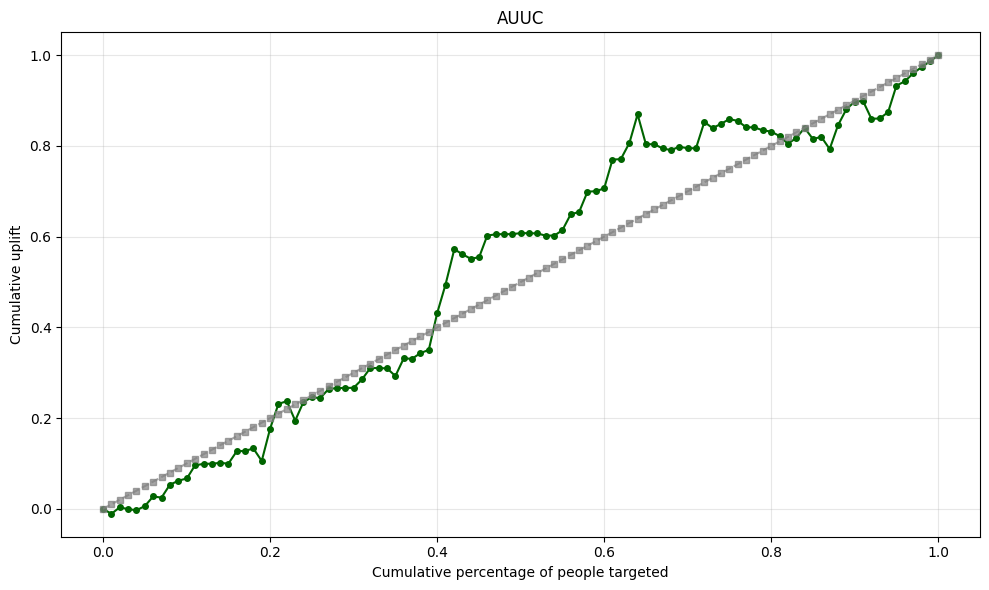

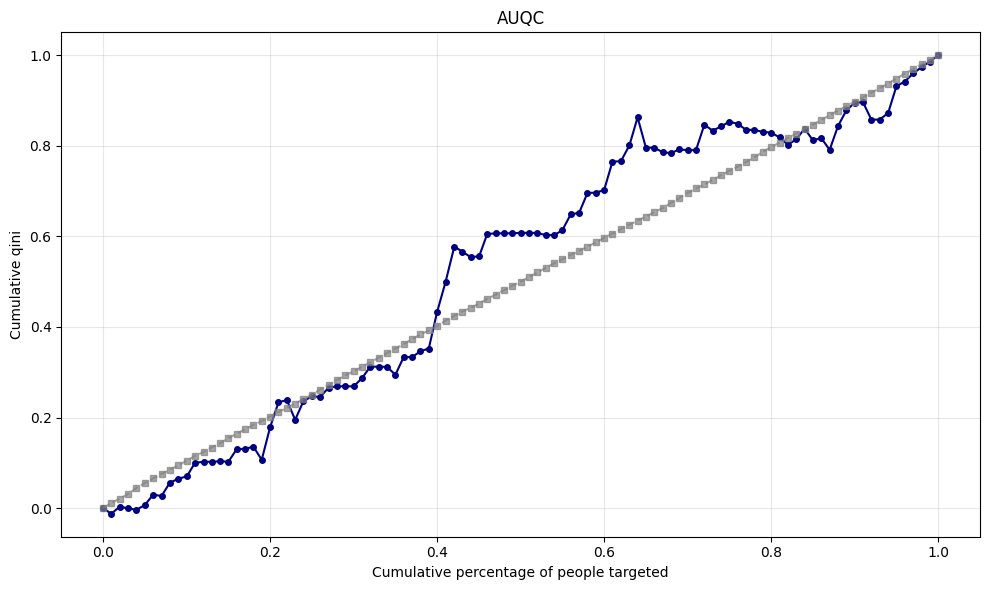

----------------------------------------
[ORIGINAL TEST SET]
AUUC: 0.529
AUQC: 0.528
Lift: 0.912
KRCC: 0.010
ATE (predicted): 0.7395
ATE (true): 1.0265
ATE error: 0.2870


In [15]:
seed = 1
seed_everything(seed)

tarnet = Tarnet(input_dim=x_men_train_t.shape[1], epochs=epochs, 
                      learning_rate=lr, 
                      weight_decay=wd,
                      use_ema=ema,
                      ema_alpha=ema_alpha,
                      patience=patience,
                      shared_hidden=shared_hidden,
                      outcome_hidden=outcome_hidden,
                      outcome_dropout=outcome_droupout,
                      shared_dropout=shared_dropout,
                      early_stop_metric=early_stop_metric,
                      early_stop_start_epoch=early_stop_start,
)
tarnet.fit(train_loader, val_loader)

print ("Complete training")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Evaluate on ORIGINAL test set ===
print("=" * 50)
print("Evaluating on ORIGINAL test set 🔃🔃🔃")
x_men_test_t_on_device = x_men_test_t.to(device)
y0_pred, y1_pred = tarnet.predict(x_men_test_t_on_device)
uplift_pred = (y1_pred - y0_pred).cpu().numpy().flatten()
y_true = y_men_test_t.cpu().numpy().flatten()
t_true = t_men_test_t.cpu().numpy().flatten()

auuc_score = auuc(y_true, t_true, uplift_pred, bins=100, plot=True)
auqc_score = auqc(y_true, t_true, uplift_pred, bins=100, plot=True)
lift_score = lift(y_true, t_true, uplift_pred, h=0.3)
krcc_score = krcc(y_true, t_true, uplift_pred, bins=100)
ate_pred = uplift_pred.mean()
ate_true = y_true[t_true == 1].mean() - y_true[t_true == 0].mean()

print("-" * 40)
print("[ORIGINAL TEST SET]")
print(f"AUUC: {auuc_score:.3f}")
print(f"AUQC: {auqc_score:.3f}")
print(f"Lift: {lift_score:.3f}")
print(f"KRCC: {krcc_score:.3f}")
print(f"ATE (predicted): {ate_pred:.4f}")
print(f"ATE (true): {ate_true:.4f}")
print(f"ATE error: {abs(ate_pred - ate_true):.4f}")